## Supp Fig2 J:  Combined Volcanos Plots 

In [1]:
suppressPackageStartupMessages({
    require(data.table)
require(ggplot2)
require(dplyr)
require(tidyr)
require(parallel)
require(ggridges)
library(ggrepel)
    })
source('../utilities/functions/helper_functions_olink.R')

In [2]:
plasma_healthy_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_comparisons_to_healthy.csv')

In [3]:
# Color map and thresholds
tp_color_map <- c(
  "PreTx"   = "#8B0000",
  "EI"      = "#7502C2",
  "ASCT60d" = "#0021B0",
  "ASCT90d" = "#2346DE",
  "ASCT1y"  = "#038AFF",
  "ASCT2y"  = "#008080",
  "Healthy" = "#00470D"
)
alpha_thresh <- 0.05
lfc_thresh   <- 0.5

# Prep data
# Extract timepoint from contrast name and order facets to match tp_color_map
plasma_healthy_comparisons$tp <- sub("-Healthy$", "", plasma_healthy_comparisons$Contrast)
plasma_healthy_comparisons <- plasma_healthy_comparisons[plasma_healthy_comparisons$tp != "PI2C", ]
plasma_healthy_comparisons$Contrast <- factor(
  plasma_healthy_comparisons$Contrast,
  levels = unique(plasma_healthy_comparisons$Contrast[
    order(match(plasma_healthy_comparisons$tp, names(tp_color_map)))
  ])
)

# Flip fold change so positive = higher in Healthy
plasma_healthy_comparisons$Log2FC <- -plasma_healthy_comparisons$Log2FC

# Significance and color assignment
# "Up" = higher in timepoint (left), "Down" = higher in Healthy (right)
plasma_healthy_comparisons$significance <- "Not Sig"
plasma_healthy_comparisons$significance[
  plasma_healthy_comparisons$adjP < alpha_thresh & plasma_healthy_comparisons$Log2FC < -lfc_thresh
] <- "Up"
plasma_healthy_comparisons$significance[
  plasma_healthy_comparisons$adjP < alpha_thresh & plasma_healthy_comparisons$Log2FC > lfc_thresh
] <- "Down"

# Map colors: timepoint color for "Up", Healthy green for "Down", grey for NS
plasma_healthy_comparisons$color_group <- ifelse(
  plasma_healthy_comparisons$significance == "Up",
  plasma_healthy_comparisons$tp,
  ifelse(plasma_healthy_comparisons$significance == "Down",
         "Healthy", "Not Sig")
)

color_values <- c(tp_color_map, "Not Sig" = "gray70")

In [4]:
# Plot
p <- ggplot(plasma_healthy_comparisons,
            aes(x = Log2FC, y = -log10(adjP),
                color = color_group, label = Assay)) +
  geom_point(size = 1, alpha = 0.8) +
  ggrepel::geom_text_repel(
    data = subset(plasma_healthy_comparisons,
                  adjP < alpha_thresh & abs(Log2FC) > lfc_thresh),
    force = 1.5, max.overlaps = 10, size = 5, show.legend = FALSE
  ) +
  geom_vline(xintercept = c(-lfc_thresh, lfc_thresh),
             linetype = "dashed", color = "grey50", linewidth = 0.5) +
  geom_hline(yintercept = -log10(alpha_thresh),
             linetype = "dashed", color = "grey50", linewidth = 0.5) +
  facet_wrap(~ Contrast, ncol = 3, scales = "free_y") +
  scale_color_manual(values = color_values, guide = "none") +
  labs(
    x = expression(Log[2] ~ Fold ~ Change),
    y = expression(-Log[10] ~ "(FDR) - Olink"),
    color = NULL
  ) +
  theme_classic(base_size = 15) +
  theme(
    strip.text = element_text(size = 15, hjust = 0, face = "bold"),
    strip.background = element_blank(),
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    legend.position = "bottom",
    legend.text = element_text(size = 11),
    panel.spacing = unit(0.5, "cm")
  )

Warning message:
“Removed 31 rows containing missing values or values outside the scale range (`geom_point()`).”


Warning message:
“ggrepel: 564 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 413 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 326 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 300 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


...

Warning message:
“ggrepel: 564 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 409 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 322 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 296 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 395 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


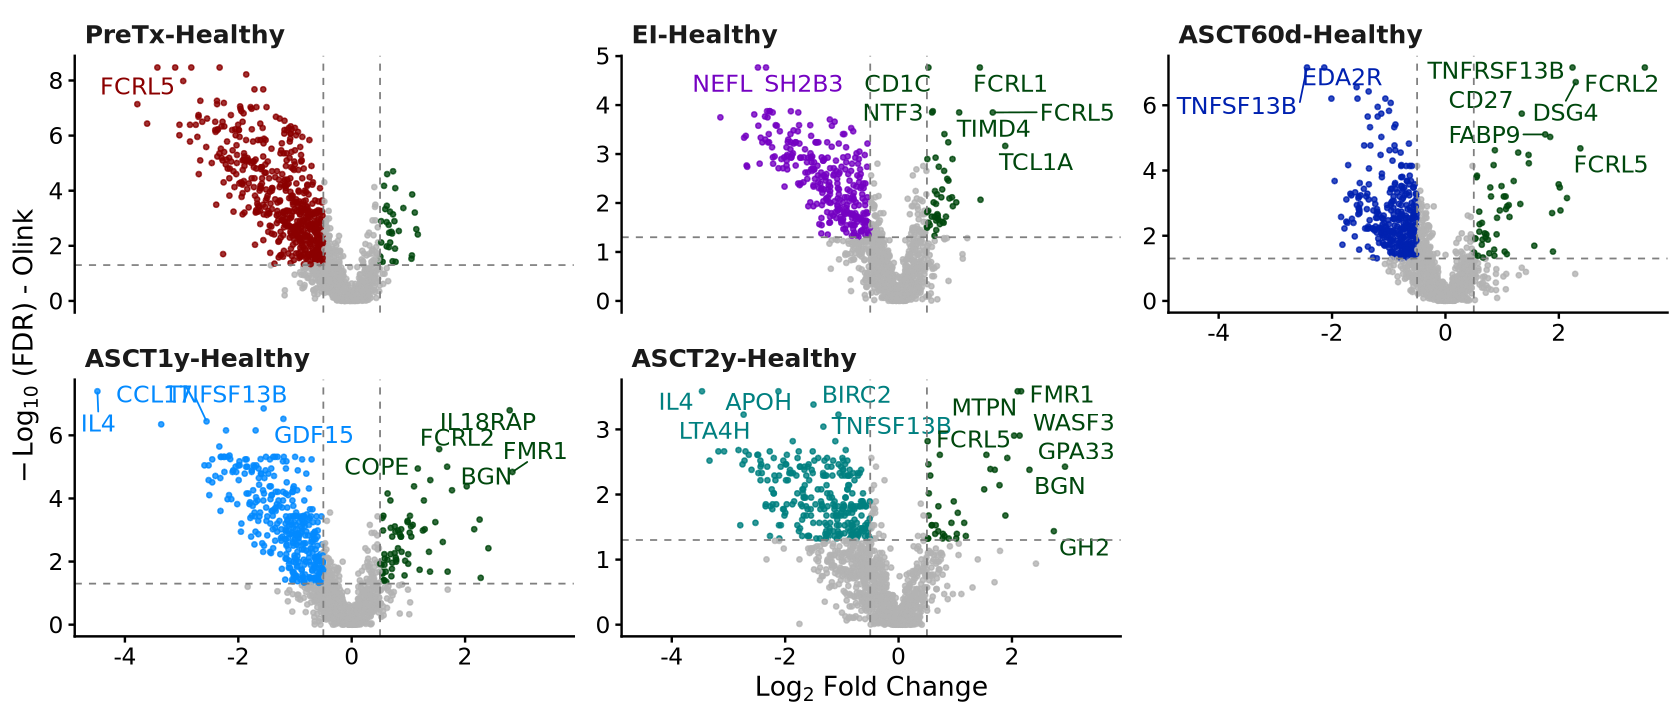

In [5]:
options(repr.plot.width = 14, repr.plot.height = 6)
p

ggsave("../../data/figure-outputs/supplementary-2/sup_2j.pdf", plot = p, width = 14, height = 6, dpi = 200, device = cairo_pdf)

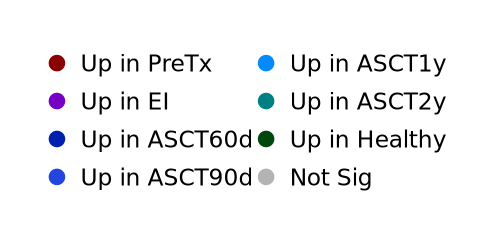

In [6]:
options(repr.plot.width = 4, repr.plot.height = 2)

legend_data <- data.frame(
  label = factor(
    c(paste("Up in", names(tp_color_map)), "Not Sig"),
    levels = c(paste("Up in", names(tp_color_map)), "Not Sig")
  ),
  color = c(unname(tp_color_map), "gray70"),
  x = seq_len(length(tp_color_map) + 1),
  y = 1
)
p_legend <- ggplot(legend_data, aes(x = x, y = y, color = label)) +
  geom_point(size = 4) +
  scale_color_manual(values = setNames(legend_data$color, legend_data$label)) +
  guides(color = guide_legend(nrow = 4)) +
  theme_void() +
  theme(
    legend.position = "bottom",
    legend.text = element_text(size = 14),
    legend.title = element_blank()
  )
legend_grob <- cowplot::get_legend(p_legend)

p_out <- cowplot::ggdraw(legend_grob)
p_out

suppressWarnings(
  ggsave("../../data/figure-outputs/supplementary-2/sup_2j-legend.pdf", plot = p_out, width = 4, height = 2, dpi = 200, device = cairo_pdf)
)